In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = fetch_openml(data_id=41554, as_frame=True)
df = data.frame

In [3]:
print(df.head())
print(df.describe())
print(df.info())

    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0       1       0       0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1       0       0       0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2       1       0       0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3       0       0       0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4       0       0       1  38.52  26.20  66.40  88.40  1.565  16.32  34.32  
             Xloc        Yloc   Landuse_1   Landuse_2   Landuse

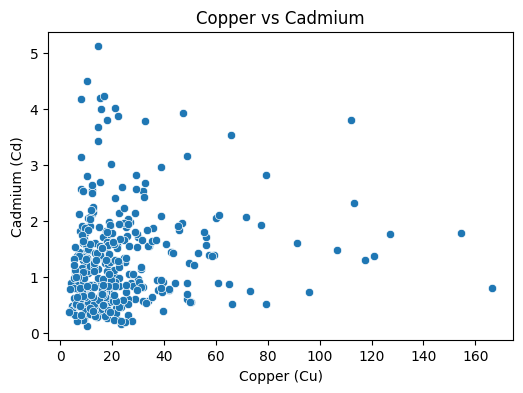

In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Cu'], y=df['Cd'])
plt.title("Copper vs Cadmium")
plt.xlabel("Copper (Cu)")
plt.ylabel("Cadmium (Cd)")
plt.show()

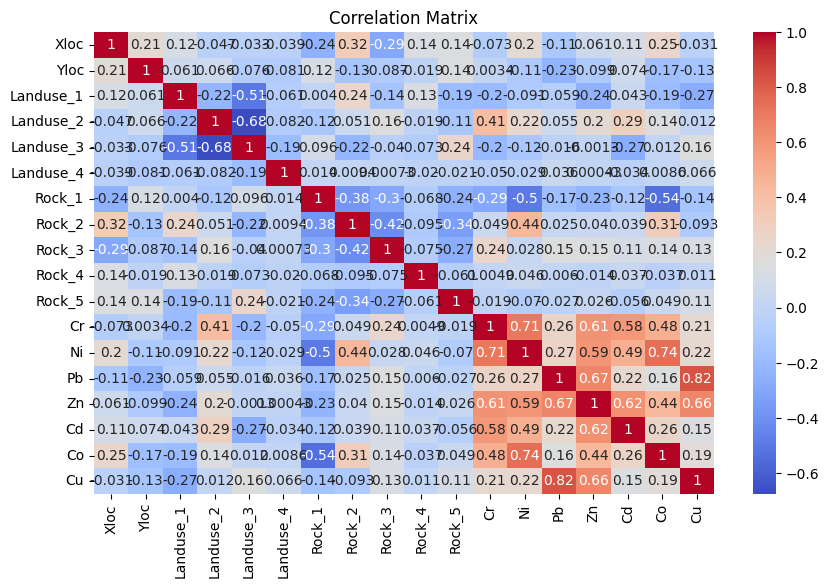

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [6]:
X = df.drop('Cd', axis=1)   
y = df['Cd']                

In [7]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [10]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [12]:
# Lasso Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [13]:
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

In [14]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_ridge, "Ridge Regression")
evaluate(y_test, y_pred_lasso, "Lasso Regression")

Linear Regression
RMSE: 0.8328470808943282
R2 Score: -0.06897541552737141
------------------------------
Ridge Regression
RMSE: 0.5436805249582448
R2 Score: 0.5444618700451495
------------------------------
Lasso Regression
RMSE: 0.8087172166439488
R2 Score: -0.007930435176925155
------------------------------


In [15]:
print("Linear Coefficients:\n", lr.coef_)
print("\nRidge Coefficients:\n", ridge.coef_)
print("\nLasso Coefficients:\n", lasso.coef_)

Linear Coefficients:
 [-1.52636106e-01  4.35489373e-01  4.17901890e-02 -6.66587332e-02
  1.05519664e-02  5.58329578e-02  8.56176263e-02  5.69267814e-02
 -6.57678219e-02 -8.22630949e-03 -8.51524800e-02  8.86594978e-01
 -6.25355180e-01 -5.36648895e-01 -2.86524139e-01  2.88164528e-01
  3.81827806e-01 -1.16107267e-01  8.79875674e-02  2.75238893e-01
 -2.45799755e-01 -1.04820650e-01  2.14590718e-02 -2.28898257e-01
  1.27735788e-01  4.49287726e-02  6.22322894e-02 -1.57998299e-01
 -2.29803299e-01 -7.99946738e-01 -7.98999718e-01  1.96001005e+00
  5.32211123e-01 -2.75045908e-01 -2.25703242e-01 -4.22650387e-03
  2.17299432e-01  1.09882955e-01  2.77746390e-01  9.48857911e-03
  2.15910942e-01  2.55054165e-02 -9.88379853e-03  1.85739321e-01
 -6.56017301e-01  8.67833029e-01  5.52332928e-01 -4.14582694e-01
 -7.47936820e-01 -3.38991789e-02  4.17901890e-02  9.36750677e-16
  2.38697950e-15 -1.73472348e-15  2.77796239e-02  7.69157662e-03
  6.75088490e-02 -3.30806015e-03 -1.16573418e-15 -1.23014582e-01
 -4

In [16]:
lasso_zero_features = np.sum(lasso.coef_ == 0)
print("Number of features reduced to zero by Lasso:", lasso_zero_features)

Number of features reduced to zero by Lasso: 170
